# Fase 6 — Validação Supervisionada
**Projeto:** Deriva de Pauta nas Notícias do CNJ

**Pergunta:** os **rótulos fracos** do BERTopic (atribuições brutas do HDBSCAN)
são consistentes o bastante para (a) serem aprendidos por um classificador a
partir de features lexicais independentes e (b) concordarem com um **gold set
anotado manualmente**?

**Desenho (anti-circularidade):**
- *Features*: TF-IDF (1–2 gramas) sobre `título + corpo_norm` — espaço lexical,
  **distinto** do espaço de embeddings/UMAP que gerou os clusters.
- *Rótulos fracos*: `topic_raw` (exclui outliers -1).
- *Gold set*: `reports/gold_labels.csv` (~195 notícias, amostra estratificada;
  rótulo atribuído por **leitura de título/lead** contra a taxonomia de 10
  tópicos; "indefinido" para ambíguos, excluídos das métricas).

Reexecute: `python src/supervised.py` (gera `supervised_metrics.json` e a
matriz de confusão). Este notebook reexecuta o essencial para exibição.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from supervised import load_dataset
from drift import TOPIC_LABELS
from topics import get_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
SEED = 42
df = load_dataset()
weak = df[df["topic_raw"] != -1].copy()
print(f"{len(df)} docs | {len(weak)} com rótulo fraco | "
      f"{len(df)-len(weak)} outliers")

979 docs | 691 com rótulo fraco | 288 outliers


## 1. Aprendizagem dos rótulos fracos (avaliação intrínseca)

Treina/testa (75/25, estratificado) sobre os rótulos fracos. Mede se as
features lexicais reproduzem as atribuições do BERTopic.

In [2]:
vec = TfidfVectorizer(stop_words=get_stopwords(), ngram_range=(1, 2),
                      min_df=3, max_features=20000, sublinear_tf=True)
X = vec.fit_transform(weak["text"]); y = weak["topic_raw"].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25,
                                      random_state=SEED, stratify=y)
clfs = {"LogReg": LogisticRegression(max_iter=2000, C=10.0,
                                     class_weight="balanced"),
        "LinearSVM": LinearSVC(C=1.0, class_weight="balanced")}
rows = []
for name, clf in clfs.items():
    clf.fit(Xtr, ytr); p = clf.predict(Xte)
    rows.append({"classificador": name,
                 "F1-macro (teste fraco)": round(f1_score(yte, p, average="macro"), 3),
                 "acurácia": round(accuracy_score(yte, p), 3)})
pd.DataFrame(rows)

,classificador,F1-macro (teste fraco),acurácia
0,LogReg,0.813,0.821
1,LinearSVM,0.806,0.815


## 2. Validação contra o gold set anotado manualmente

O classificador final é treinado em **todos** os rótulos fracos e prediz sobre o
gold. Reportamos:
- **F1-macro** e **kappa** (predição × gold) — qualidade do classificador;
- **kappa (rótulo fraco × gold)** — concordância dos próprios rótulos do
  BERTopic com o anotador humano (valida a etapa não supervisionada).

In [3]:
gold = pd.read_csv(ROOT / "reports" / "gold_labels.csv", dtype={"gold": str})
n_indef = int((gold["gold"] == "indefinido").sum())
gold = gold[gold["gold"] != "indefinido"].copy(); gold["gold"] = gold["gold"].astype(int)
gdf = gold.merge(df[["id", "text", "topic_raw"]], on="id")

final = LogisticRegression(max_iter=2000, C=10.0, class_weight="balanced").fit(X, y)
gpred = final.predict(vec.transform(gdf["text"]))

f1_gold = f1_score(gdf["gold"], gpred, average="macro")
kappa_pg = cohen_kappa_score(gdf["gold"], gpred)
m = gdf["topic_raw"] != -1
kappa_wg = cohen_kappa_score(gdf.loc[m, "gold"], gdf.loc[m, "topic_raw"])
acc_wg = accuracy_score(gdf.loc[m, "gold"], gdf.loc[m, "topic_raw"])
print(f"Gold rotulado: {len(gold)} (+{n_indef} 'indefinido' excluídos)")
print(f"F1-macro (predição × gold) : {f1_gold:.3f}")
print(f"kappa    (predição × gold) : {kappa_pg:.3f}")
print(f"kappa    (rótulo fraco × gold): {kappa_wg:.3f}  (n={int(m.sum())}, acc={acc_wg:.3f})")

Gold rotulado: 173 (+22 'indefinido' excluídos)
F1-macro (predição × gold) : 0.914
kappa    (predição × gold) : 0.910
kappa    (rótulo fraco × gold): 0.911  (n=162, acc=0.920)


In [4]:
labels = sorted(set(gdf["gold"]) | set(gpred))
names = [f"T{l} {TOPIC_LABELS.get(l, '')[:16]}" for l in labels]
print(classification_report(gdf["gold"], gpred, labels=labels,
                            target_names=names, zero_division=0))

                     precision    recall  f1-score   support

T0 Justiça itineran       0.89      0.85      0.87        20
T1 IA / Conecta / J       1.00      0.91      0.95        22
T2 Saúde / judicial       0.80      1.00      0.89        12
T3 Direitos humanos       0.69      0.85      0.76        13
T4 Violência domést       0.94      0.94      0.94        18
T5 Sistema prisiona       0.93      0.93      0.93        15
T6 Infância e juven       1.00      1.00      1.00        20
T7 Sustentabilidade       1.00      1.00      1.00        17
T8 Processos discip       1.00      1.00      1.00        18
T9 Precatórios / co       0.87      0.72      0.79        18

           accuracy                           0.92       173
          macro avg       0.91      0.92      0.91       173
       weighted avg       0.93      0.92      0.92       173



## 3. Matriz de confusão (gold × predição)

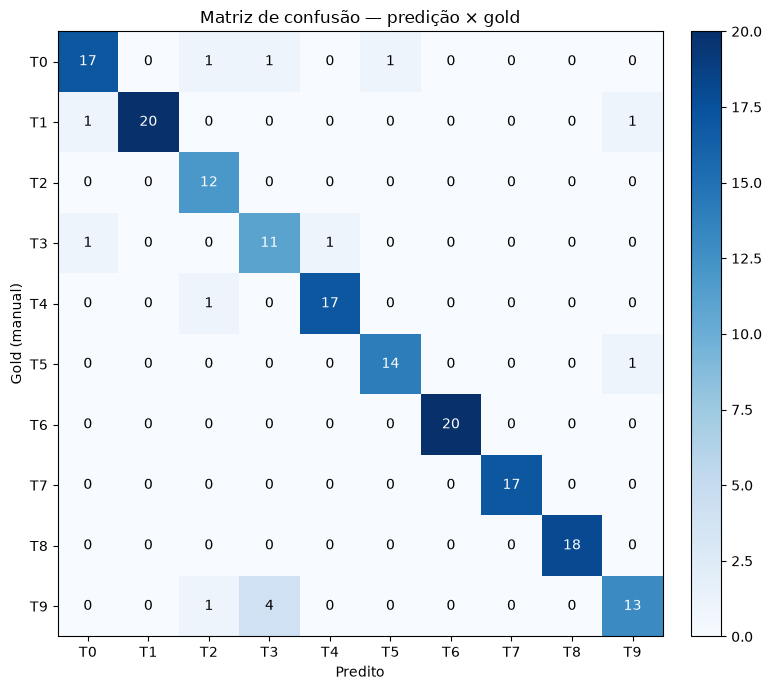

In [5]:
cm = confusion_matrix(gdf["gold"], gpred, labels=labels)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), [f"T{l}" for l in labels])
ax.set_yticks(range(len(labels)), [f"T{l}" for l in labels])
ax.set_xlabel("Predito"); ax.set_ylabel("Gold (manual)")
ax.set_title("Matriz de confusão — predição × gold")
thr = cm.max()/2
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thr else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
FIG = ROOT / "reports" / "figures"
plt.tight_layout(); plt.savefig(FIG / "13_confusion_matrix.png"); plt.show()

## Síntese da Fase 6

- **Rótulos fracos são aprendíveis:** F1-macro ≈ **0,81** (LogReg/SVM) num espaço
  de features (TF-IDF) **independente** do que gerou os clusters — os tópicos têm
  assinatura lexical clara.
- **Concordância quase-perfeita com o gold:** F1-macro = **0,91** e
  kappa = **0,91** (predição × gold).
- **A etapa não supervisionada se valida:** kappa (rótulo fraco × gold) = **0,91**
  (acurácia 0,92) — as atribuições brutas do BERTopic já concordam fortemente com
  a leitura humana.
- **Erros concentrados (resultado honesto):** os tópicos mais largos/
  institucionais — *T3 direitos humanos* (f1≈0,76) e *T9 precatórios/corregedoria*
  (f1≈0,79) — confundem-se entre si (ex.: decisões administrativas do CNJ).
  Tópicos temáticos nítidos (*infância*, *sustentabilidade*, *disciplinares*)
  atingem f1 = 1,0.
- A anotação manual também **corrigiu rótulos fracos equivocados** detectados na
  amostragem (ex.: "Julgamentos de feminicídio aumentam 17%" rotulado como
  *saúde* pelo modelo → *violência/mulheres* no gold), o que explica parte das
  divergências.

Todos os números vêm da execução real de `src/supervised.py`
(`data/processed/supervised_metrics.json`).